In [ ]:
import math
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [29]:
FILE_PATH = "/Users/saranyapal/Developer/grid-determination-bizom/data/delhi_grids.csv"
df = pd.read_csv(FILE_PATH)
df.shape

(2000, 14)

In [30]:
df.columns

Index(['grid_id', 'latitude', 'longitude', 'building_count',
       'yellow_building_count', 'building_density', 'yellow_building_density',
       'total_building_density', 'main_road_density', 'local_road_density',
       'total_road_density', 'waterbody', 'water_percent', 'empty'],
      dtype='object')

In [31]:
new_df = df.copy(deep=True)
vis_df_1 = new_df.drop(columns=["grid_id", "latitude", "longitude"], axis=1)
vis_df_1.columns

Index(['building_count', 'yellow_building_count', 'building_density',
       'yellow_building_density', 'total_building_density',
       'main_road_density', 'local_road_density', 'total_road_density',
       'waterbody', 'water_percent', 'empty'],
      dtype='object')

#### Checking Correlations

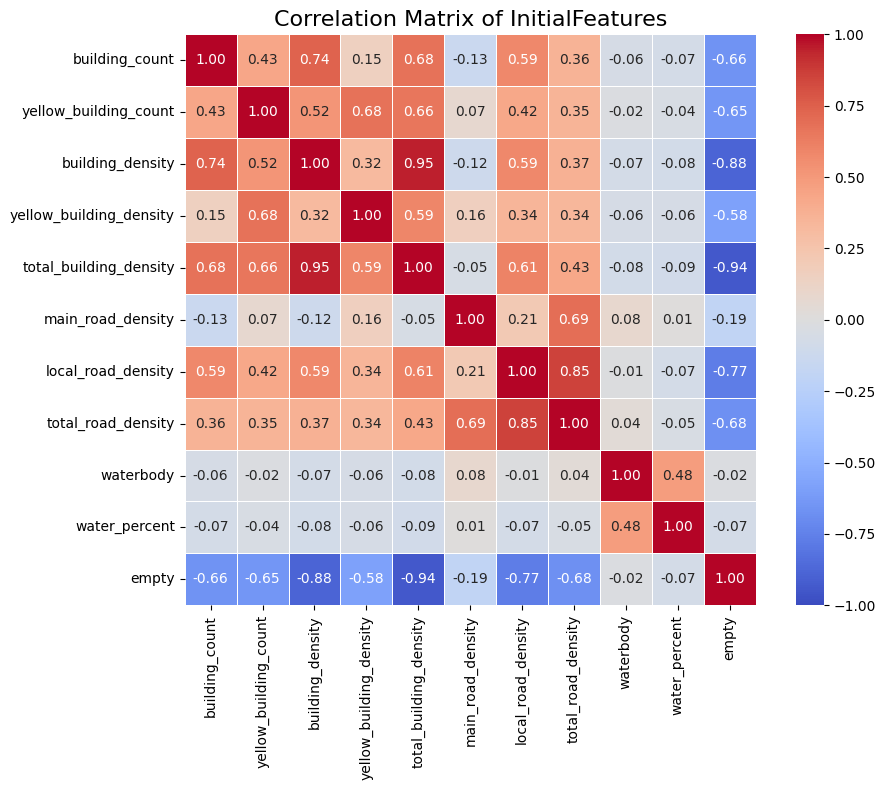

In [ ]:
corr_matrix = vis_df_1.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title("Correlation Matrix of InitialFeatures", fontsize=16)
plt.tight_layout()

In [33]:
corr_matrix

,building_count,yellow_building_count,building_density,yellow_building_density,total_building_density,main_road_density,local_road_density,total_road_density,waterbody,water_percent,empty
building_count,1.000000,0.432652,0.739247,0.151648,0.678316,-0.133021,0.585129,0.363873,-0.062087,-0.071070,-0.660659
yellow_building_count,0.432652,1.000000,0.522322,0.677117,0.661333,0.072294,0.424756,0.353773,-0.017648,-0.042264,-0.648139
building_density,0.739247,0.522322,1.000000,0.315942,0.952970,-0.116718,0.585346,0.372689,-0.073240,-0.084050,-0.883974
yellow_building_density,0.151648,0.677117,0.315942,1.000000,0.588624,0.159298,0.344514,0.340372,-0.062027,-0.058263,-0.582156
total_building_density,0.678316,0.661333,0.952970,0.588624,1.000000,-0.048566,0.608791,0.426273,-0.082217,-0.090225,-0.939145
main_road_density,-0.133021,0.072294,-0.116718,0.159298,-0.048566,1.000000,0.211695,0.688000,0.079424,0.012253,-0.194774
local_road_density,0.585129,0.424756,0.585346,0.344514,0.608791,0.211695,1.000000,0.854909,-0.008615,-0.071743,-0.769921
total_road_density,0.363873,0.353773,0.372689,0.340372,0.426273,0.688000,0.854909,1.000000,0.035762,-0.046768,-0.675085
waterbody,-0.062087,-0.017648,-0.073240,-0.062027,-0.082217,0.079424,-0.008615,0.035762,1.000000,0.482289,-0.023200
water_percent,-0.071070,-0.042264,-0.084050,-0.058263,-0.090225,0.012253,-0.071743,-0.046768,0.482289,1.000000,-0.072295


#### Checking Data Dsitributions

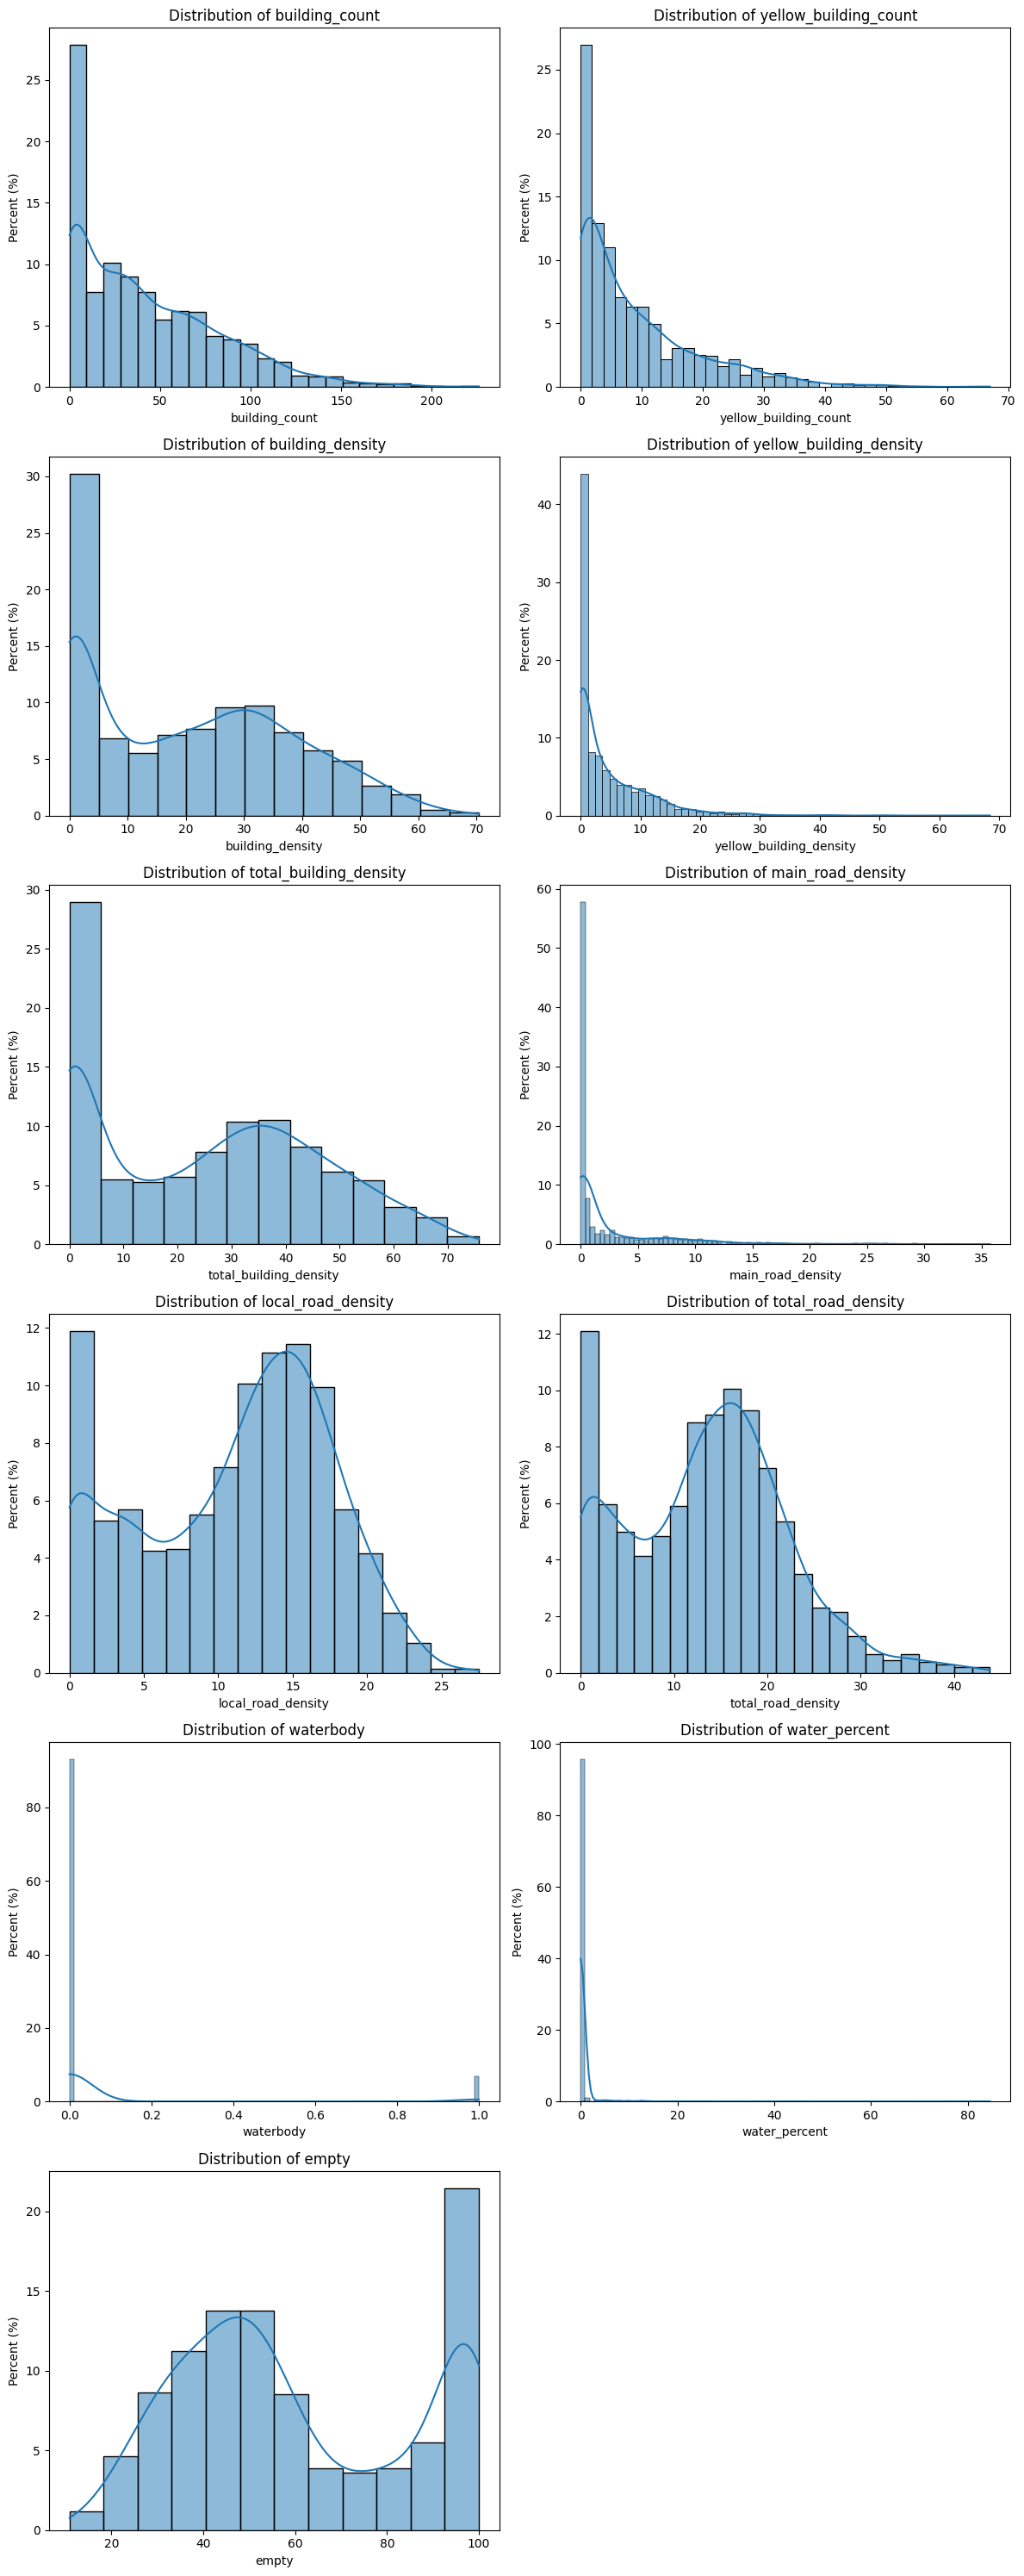

In [34]:
import math

num_cols = len(vis_df_1.columns)
num_rows = math.ceil(num_cols / 2)

fig, axes = plt.subplots(num_rows, 2, figsize=(12, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(vis_df_1.columns):
    sns.histplot(data=vis_df_1, x=col, kde=True, ax=axes[i], stat="percent")

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Percent (%)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### Observations:

1. Data Distribtuion:
- `building_count`, `yellow_building_density`, `main_road_density`, and `local_road_density` are highly right-skewed
- `empty` has a massive spike at 100%

SOLUTION: 
Use a Log Transformation (np.log1p()) or a Power Transformer (like Yeo-Johnson in sklearn)

2. Relations we know:
- total_building_density = local_building_density + building_density
- total_road_density = local_road_density + main_road_density


3. Correlation:
- total_building_density vs. building_density (0.952970)
- total_road_density vs. local_road_density (0.854909)
- empty vs. total_building_density (-0.939145)
- building_count vs. building_density (0.739247)


SOLUTION:
- Drop building_density, Keep total_building_density
- Drop local_road_density and main_road_density

In [35]:
def safe_divide(a, b):
    return np.where(b <= 2, 0, a / b)

In [36]:
vis_df_1.columns

Index(['building_count', 'yellow_building_count', 'building_density',
       'yellow_building_density', 'total_building_density',
       'main_road_density', 'local_road_density', 'total_road_density',
       'waterbody', 'water_percent', 'empty'],
      dtype='object')

In [37]:
vis_df_1["usable_area_percent"] = 100.0 - (
    vis_df_1["empty"] + vis_df_1["water_percent"]
)

vis_df_1["kirana_potential_index"] = np.log2(
    1 + vis_df_1["yellow_building_count"]
) * safe_divide(vis_df_1["yellow_building_density"], vis_df_1["total_building_density"])

vis_df_1["local_road_proportion"] = safe_divide(
    vis_df_1["local_road_density"], vis_df_1["total_road_density"]
)

In [38]:
vis_df_1.columns

Index(['building_count', 'yellow_building_count', 'building_density',
       'yellow_building_density', 'total_building_density',
       'main_road_density', 'local_road_density', 'total_road_density',
       'waterbody', 'water_percent', 'empty', 'usable_area_percent',
       'kirana_potential_index', 'local_road_proportion'],
      dtype='object')

In [39]:
columns_to_drop = [
    "building_count",
    "building_density",
    "main_road_density",
    "local_road_density",
    "waterbody",
    "empty",  # We drop this because of the -0.93 correlation with building density
]

vis_df_2 = vis_df_1.drop(columns=columns_to_drop, axis=1)
vis_df_2.columns

Index(['yellow_building_count', 'yellow_building_density',
       'total_building_density', 'total_road_density', 'water_percent',
       'usable_area_percent', 'kirana_potential_index',
       'local_road_proportion'],
      dtype='object')

In [40]:
corr_matrix_2 = vis_df_2.corr()
corr_matrix_2

,yellow_building_count,yellow_building_density,total_building_density,total_road_density,water_percent,usable_area_percent,kirana_potential_index,local_road_proportion
yellow_building_count,1.000000,0.677117,0.661333,0.353773,-0.042264,0.654078,0.668231,0.273411
yellow_building_density,0.677117,1.000000,0.588624,0.340372,-0.058263,0.590757,0.890688,0.174547
total_building_density,0.661333,0.588624,1.000000,0.426273,-0.090225,0.952415,0.429333,0.478094
total_road_density,0.353773,0.340372,0.426273,1.000000,-0.046768,0.681713,0.433059,0.252980
water_percent,-0.042264,-0.058263,-0.090225,-0.046768,1.000000,-0.088731,-0.044358,-0.069134
usable_area_percent,0.654078,0.590757,0.952415,0.681713,-0.088731,1.000000,0.493156,0.471916
kirana_potential_index,0.668231,0.890688,0.429333,0.433059,-0.044358,0.493156,1.000000,0.116450
local_road_proportion,0.273411,0.174547,0.478094,0.252980,-0.069134,0.471916,0.116450,1.000000


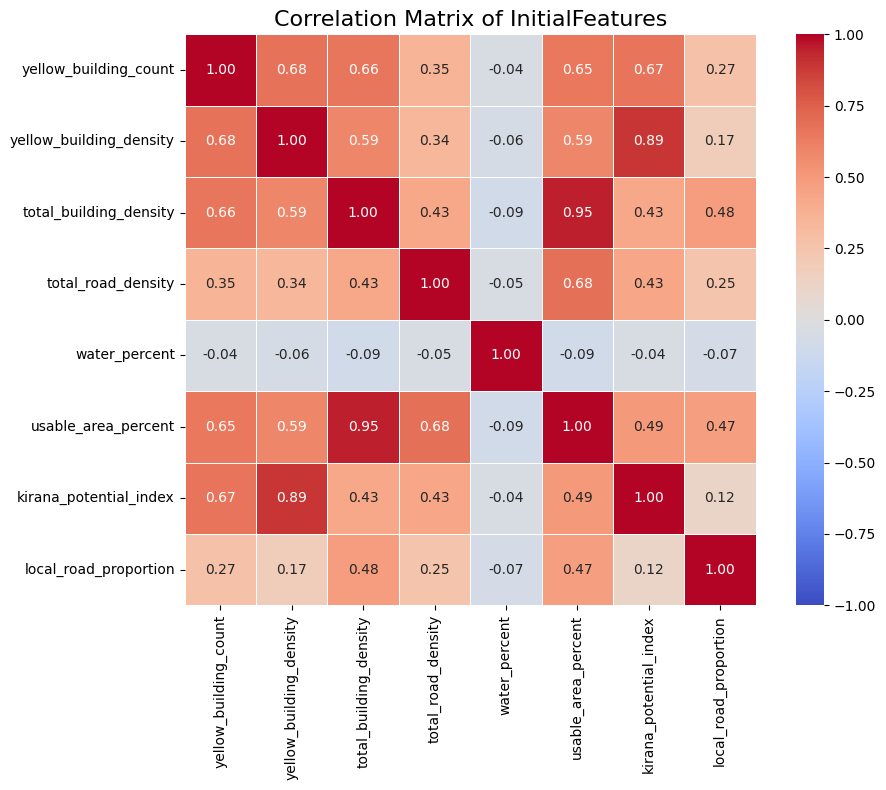

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix_2,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title("Correlation Matrix of InitialFeatures", fontsize=16)
plt.tight_layout()

In [42]:
columns_to_drop_2 = [
    "usable_area_percent",
    "yellow_building_density",
    "yellow_building_count",
    "total_road_density",
]

vis_df_3 = vis_df_2.drop(columns=columns_to_drop_2, axis=1)
vis_df_3.columns

Index(['total_building_density', 'water_percent', 'kirana_potential_index',
       'local_road_proportion'],
      dtype='object')

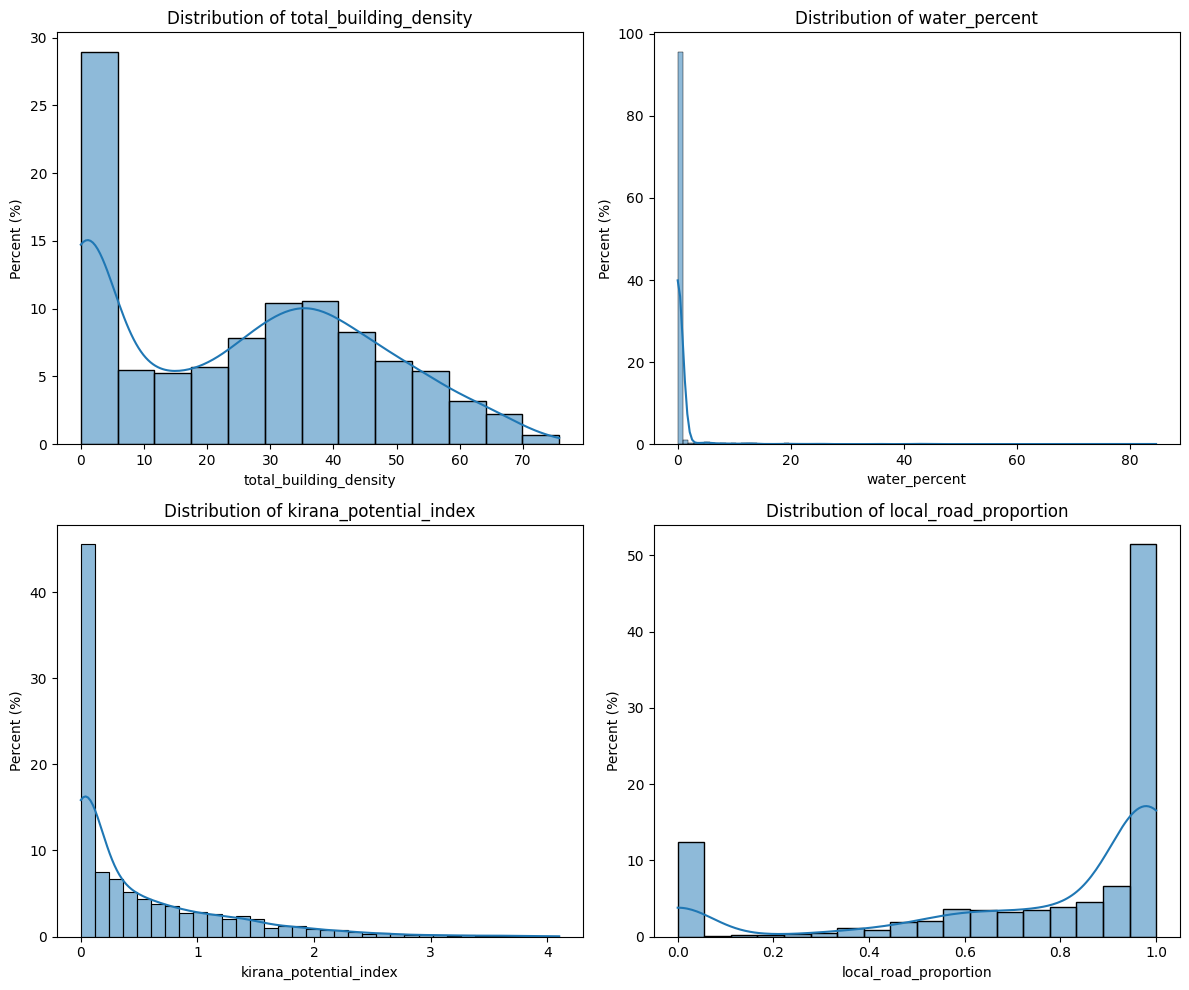

In [43]:
import math

num_cols = len(vis_df_3.columns)
num_rows = math.ceil(num_cols / 2)

fig, axes = plt.subplots(num_rows, 2, figsize=(12, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(vis_df_3.columns):
    sns.histplot(data=vis_df_3, x=col, kde=True, ax=axes[i], stat="percent")

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Percent (%)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [44]:
def apply_log_transform(val: float):
    return np.log1p(val)


vis_df_3["water_percent_log"] = vis_df_3["water_percent"].apply(apply_log_transform)
vis_df_3["kirana_potential_index_log"] = vis_df_3["kirana_potential_index"].apply(
    apply_log_transform
)


columns_to_drop_3 = ["water_percent", "kirana_potential_index"]
vis_df_4 = vis_df_3.drop(columns=columns_to_drop_3, axis=1)
vis_df_4.columns

Index(['total_building_density', 'local_road_proportion', 'water_percent_log',
       'kirana_potential_index_log'],
      dtype='object')

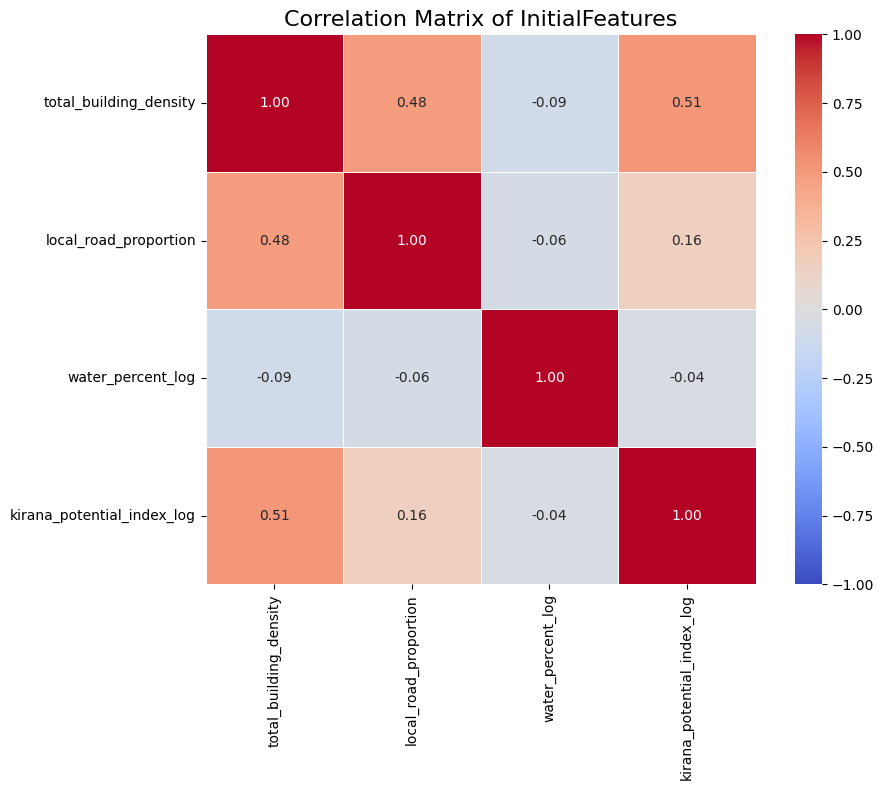

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    vis_df_4.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title("Correlation Matrix of InitialFeatures", fontsize=16)
plt.tight_layout()

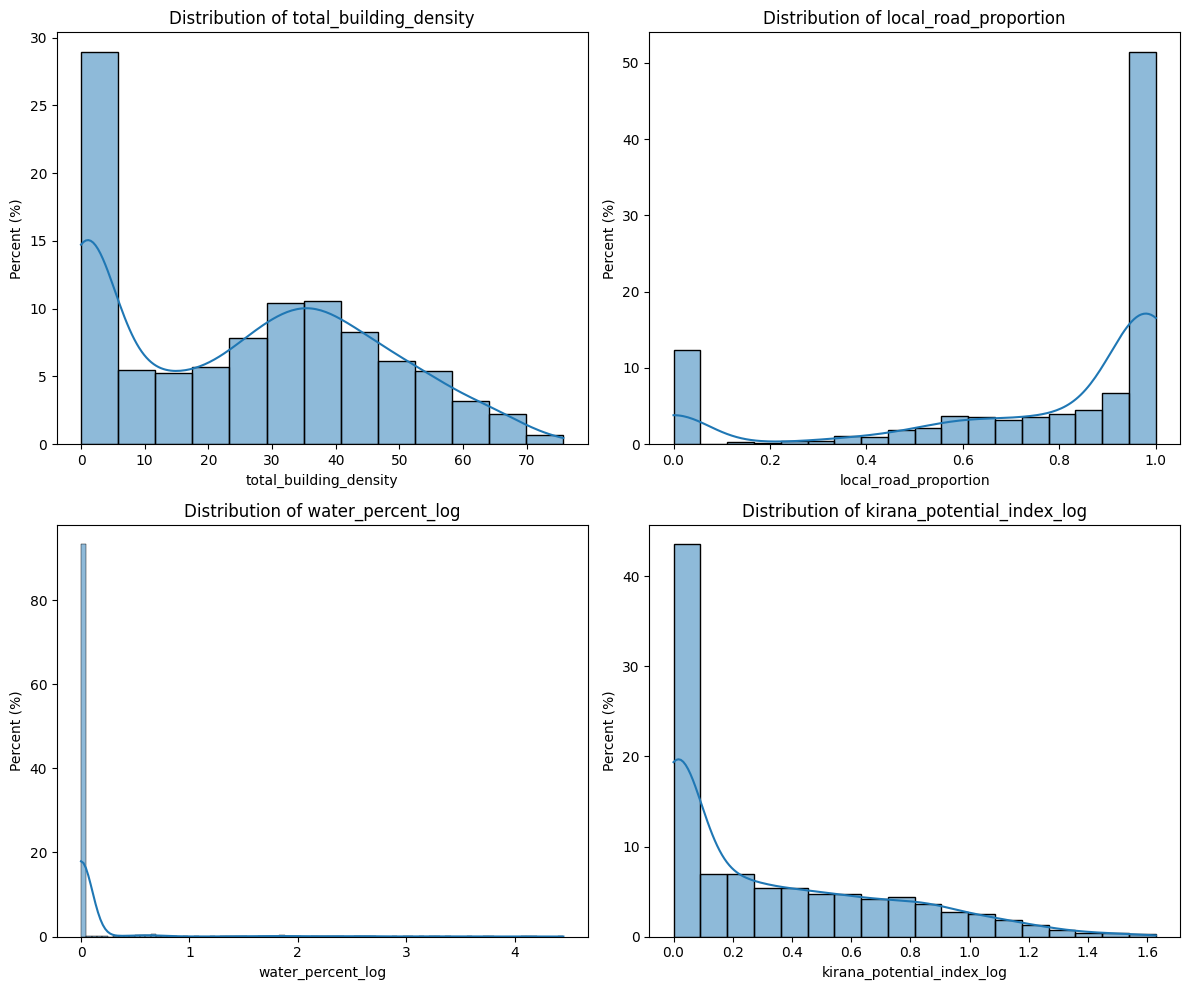

In [ ]:
num_cols = len(vis_df_4.columns)
num_rows = math.ceil(num_cols / 2)

fig, axes = plt.subplots(num_rows, 2, figsize=(12, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(vis_df_4.columns):
    sns.histplot(data=vis_df_4, x=col, kde=True, ax=axes[i], stat="percent")

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Percent (%)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [47]:
vis_df_4.head()

,total_building_density,local_road_proportion,water_percent_log,kirana_potential_index_log
0,0.00,0.0,0.0,0.0
1,0.06,0.0,0.0,0.0
2,0.71,1.0,0.0,0.0
3,1.94,1.0,0.0,0.0
4,2.85,1.0,0.0,0.0


In [48]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

In [49]:
X_scaled = StandardScaler().fit_transform(vis_df_4)
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
labels = gmm.fit_predict(X_scaled)
probs = gmm.predict_proba(X_scaled)

vis_df_4["labels"] = labels
for i in range(probs.shape[1]):
    vis_df_4[f"prob_cluster_{i}"] = probs[:, i]

In [50]:
vis_df_4["labels"].value_counts()

labels
1    1649
2     212
0     139
Name: count, dtype: int64

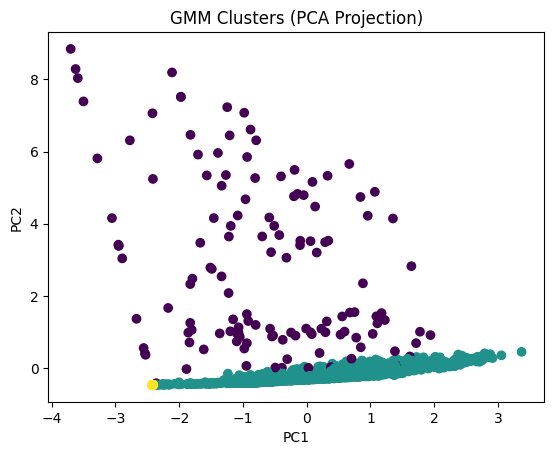

In [51]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters (PCA Projection)")
plt.show()

In [55]:
vis_df_4.sort_values(by="water_percent_log", ascending=False).head(3)

,total_building_density,local_road_proportion,water_percent_log,kirana_potential_index_log,labels,prob_cluster_0,prob_cluster_1,prob_cluster_2
48,0.0,0.000000,4.449685,0.0,0,1.0,0.0,0.0
224,0.0,0.000000,4.183576,0.0,0,1.0,0.0,0.0
245,0.0,0.971671,4.110054,0.0,0,1.0,0.0,0.0


In [56]:
vis_df_4.sort_values(by="total_building_density", ascending=False).head(3)

,total_building_density,local_road_proportion,water_percent_log,kirana_potential_index_log,labels,prob_cluster_0,prob_cluster_1,prob_cluster_2
1687,75.74,0.960000,0.0,0.658946,1,0.000003,0.999997,0.0
1965,75.58,0.994574,0.0,0.567446,1,0.000003,0.999997,0.0
1700,75.35,0.984699,0.0,0.858982,1,0.000003,0.999997,0.0


#### Final features distribution and correlation

In [ ]:
from grid_determination_bizom.data_pipeline.data_loader_and_transformer import (
    DataFrameFeatureTransformer,
)

In [ ]:
#   Distribution of Finalized features

num_cols = len(vis_df_3.columns)
num_rows = math.ceil(num_cols / 2)

fig, axes = plt.subplots(num_rows, 2, figsize=(12, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(vis_df_3.columns):
    sns.histplot(data=vis_df_3, x=col, kde=True, ax=axes[i], stat="percent")

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Percent (%)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()